In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process
import importlib
from tqdm.auto import tqdm
import multiprocessing as mp
from scipy import stats 

### Run stats on human results 
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm
from statsmodels.formula.api import ols

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# So that we can edit the text in illustrator
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
# fig_out_dir = Path("final_figures/figure_4")
# fig_out_dir.mkdir(exist_ok=True, parents=True)


# Load pre-computed human threshold data

In [17]:
path_to_human_results = Path('final_results_dir')
human_thresh_df = pd.read_csv(path_to_human_results / 'human_threshold_raw_data_N-33.csv')
N = 33
human_thresh_df.head()

,participant,target_azim,target_elev,distractor_azim,distractor_elev_delta,snr,n_distractors,correct_mean,correct_sem,confusions_mean,confusions_sem,confusions_count
0,participant_001,0,40,-60,0,-9,2,0.1875,0.100778,0.5625,0.128087,16
1,participant_001,0,40,-60,0,-6,2,0.3125,0.119678,0.2500,0.111803,16
2,participant_001,0,40,-60,0,-3,2,0.4375,0.128087,0.0625,0.062500,16
3,participant_001,0,40,-60,0,0,2,0.5625,0.128087,0.0000,0.000000,16
4,participant_001,0,40,-60,0,3,2,0.8750,0.085391,0.0000,0.000000,16


## The ones to use

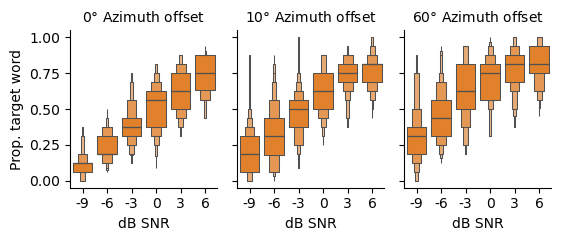

In [93]:
## Plot participant level data 
human_thresh_df['azim_delta'] = human_thresh_df['distractor_azim'].abs()

g = sns.catplot(data=human_thresh_df[human_thresh_df.distractor_elev_delta==0],
                    x='snr',
                    y='correct_mean', 
                    col="azim_delta",
                    kind='boxen',
                    k_depth='full',
                    # zorder=3,
                    # cut=0,
                    legend=False,
                    # inner="stick",
                    color='tab:orange',
                    height=2.5,
                    aspect=0.75,
                )
                    

g.set(
    # xticks=np.arange(-9, 7, 3), 
      xlabel='dB SNR',
      ylabel='Prop. target word',
    #   yticks=[0, 0.25, 0.5, 0.75, 1]
      )# c

# g.refline(y=0.5, linestyle='--', color='k', linewidth=0.75, alpha=0.5, zorder=1)

g.set_titles("{col_name}$\degree$ Azimuth offset")

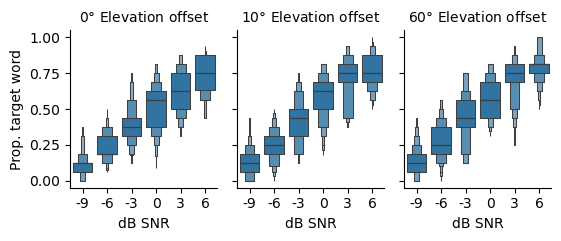

In [92]:
## Plot participant level data 
human_thresh_df['azim_delta'] = human_thresh_df['distractor_azim'].abs()

g = sns.catplot(data=human_thresh_df[human_thresh_df.azim_delta==0],
                    x='snr', y='correct_mean', 
                    col="distractor_elev_delta",
                    kind='boxen',
                    k_depth='full',
                    # cut=0,
                    legend=False,
                    # inner="stick",
                    color='tab:blue',
                    height=2.5,
                    aspect=0.75,
                )
                    
g.set(
    # xticks=np.arange(-9, 7, 3), 
      xlabel='dB SNR',
      ylabel='Prop. target word',
    #   yticks=[0, 0.25, 0.5, 0.75, 1]
      )# column titles 

# g.refline(y=0.5, linestyle='--', color='k', linewidth=0.75, alpha=0.5, zorder=1)

g.set_titles("{col_name}$\degree$ Elevation offset")

## Old for ref

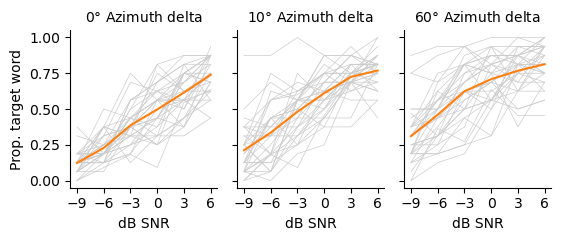

In [48]:
## Plot participant level data 
human_thresh_df['azim_delta'] = human_thresh_df['distractor_azim'].abs()

g = sns.relplot(data=human_thresh_df[human_thresh_df.distractor_elev_delta==0],
                    x='snr', y='correct_mean', 
                    col="azim_delta",
                    kind='line',
                    color='tab:orange',
                    zorder=5,
                    # col_wrap=8,
                    # row='room_str',
                    # palette=palette, 
                    # row='target_elev',
                    errorbar=None,#('se', 1),
                    # err_style='bars',
                    height=2.5,
                    aspect=0.75,
                )

for azim_delta, ax in g.axes_dict.items():

    sns.lineplot(data=human_thresh_df[(human_thresh_df.distractor_elev_delta==0)&
                                      (human_thresh_df.azim_delta==azim_delta)],
                        x='snr',
                        y='correct_mean', 
                        units='participant',
                        estimator=None, 
                        color=".8",
                        linewidth=0.5,
                        zorder=1,
                        # alpha=0.,
                        ax=ax,
                    )
                    
g.set(xticks=np.arange(-9, 7, 3), 
      xlabel='dB SNR',
      ylabel='Prop. target word',
      yticks=[0, 0.25, 0.5, 0.75, 1])# column titles 

g.set_titles("{col_name}$\degree$ Azimuth delta")

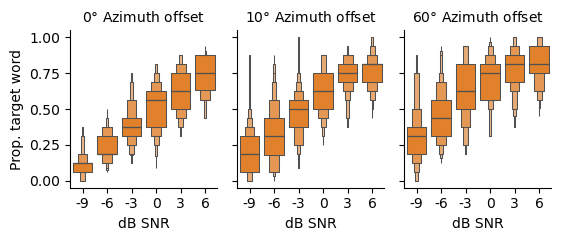

In [89]:
## Plot participant level data 
human_thresh_df['azim_delta'] = human_thresh_df['distractor_azim'].abs()

g = sns.catplot(data=human_thresh_df[human_thresh_df.distractor_elev_delta==0],
                    x='snr',
                    y='correct_mean', 
                    col="azim_delta",
                    kind='boxen',
                    k_depth='full',
                    # zorder=3,
                    # cut=0,
                    legend=False,
                    # inner="stick",
                    color='tab:orange',
                    height=2.5,
                    aspect=0.75,
                )
                    

g.set(
    # xticks=np.arange(-9, 7, 3), 
      xlabel='dB SNR',
      ylabel='Prop. target word',
    #   yticks=[0, 0.25, 0.5, 0.75, 1]
      )# c

# g.refline(y=0.5, linestyle='--', color='k', linewidth=0.75, alpha=0.5, zorder=1)

g.set_titles("{col_name}$\degree$ Azimuth offset")

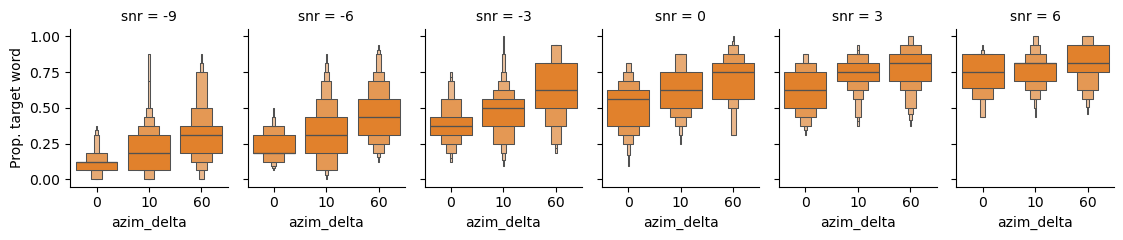

In [72]:
## Plot participant level data 
human_thresh_df['azim_delta'] = human_thresh_df['distractor_azim'].abs()

g = sns.catplot(data=human_thresh_df[human_thresh_df.distractor_elev_delta==0],
                    col='snr',
                    y='correct_mean', 
                    x="azim_delta",
                    kind='boxen',
                    k_depth='full',
                    # cut=0,
                    legend=False,
                    # inner="stick",
                    color='tab:orange',
                    height=2.5,
                    aspect=0.75,
                )
                    
g.set(
    # xticks=np.arange(-9, 7, 3), 
    #   xlabel='dB SNR',
      ylabel='Prop. target word',
    #   yticks=[0, 0.25, 0.5, 0.75, 1]
      )# column titles 

# g.set_titles("{col_name}$\degree$ Azimuth delta")

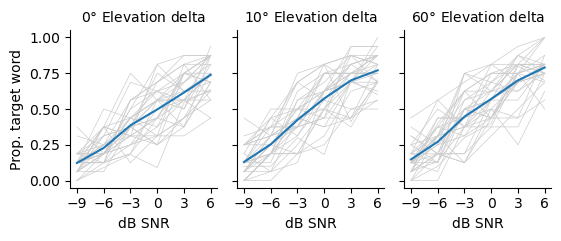

In [ ]:
## Plot participant level data 

g = sns.relplot(data=human_thresh_df[human_thresh_df.azim_delta==0],
                    x='snr', y='correct_mean', 
                    col="distractor_elev_delta",
                    errorbar=None,#('se', 1),
                    kind='line',
                    color='tab:blue',
                    height=2.5,
                    aspect=0.75,
                )

for elev_delta, ax in g.axes_dict.items():

    sns.lineplot(data=human_thresh_df[(human_thresh_df.azim_delta==0) & 
                                (human_thresh_df.distractor_elev_delta==elev_delta)],
                        x='snr',
                        y='correct_mean', 
                        units='participant',
                        estimator=None, 
                        color=".8",
                        linewidth=0.5,
                        zorder=1,
                        # alpha=0.,
                        ax=ax,
                    )
                    
g.set(xticks=np.arange(-9, 7, 3), 
      xlabel='dB SNR',
      ylabel='Prop. target word',
      yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}$\degree$ Elevation delta")


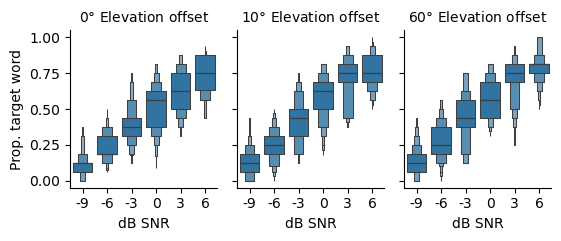

In [91]:
## Plot participant level data 
human_thresh_df['azim_delta'] = human_thresh_df['distractor_azim'].abs()

g = sns.catplot(data=human_thresh_df[human_thresh_df.azim_delta==0],
                    x='snr', y='correct_mean', 
                    col="distractor_elev_delta",
                    kind='boxen',
                    k_depth='full',
                    # cut=0,
                    legend=False,
                    # inner="stick",
                    color='tab:blue',
                    height=2.5,
                    aspect=0.75,
                )
                    
g.set(
    # xticks=np.arange(-9, 7, 3), 
      xlabel='dB SNR',
      ylabel='Prop. target word',
    #   yticks=[0, 0.25, 0.5, 0.75, 1]
      )# column titles 

# g.refline(y=0.5, linestyle='--', color='k', linewidth=0.75, alpha=0.5, zorder=1)

g.set_titles("{col_name}$\degree$ Elevation offset")

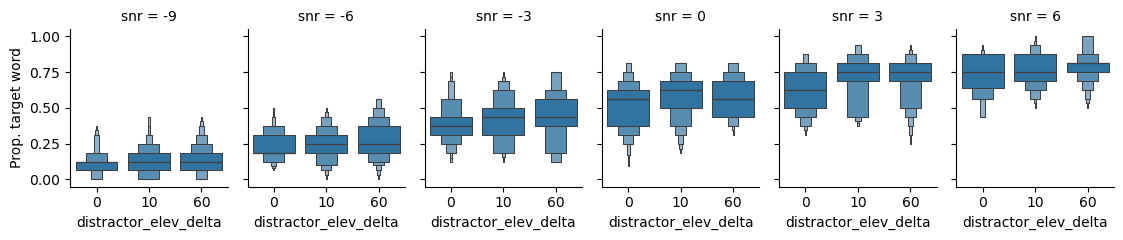

In [67]:
## Plot participant level data 
human_thresh_df['azim_delta'] = human_thresh_df['distractor_azim'].abs()

g = sns.catplot(data=human_thresh_df[human_thresh_df.azim_delta==0],
                    col='snr', y='correct_mean', 
                    x="distractor_elev_delta",
                    kind='boxen',
                    k_depth='full',
                    # cut=0,
                    legend=False,
                    # inner="stick",
                    color='tab:blue',
                    height=2.5,
                    aspect=0.75,
                )
                    
g.set(
    # xticks=np.arange(-9, 7, 3), 
    #   xlabel='dB SNR',
      ylabel='Prop. target word',
    #   yticks=[0, 0.25, 0.5, 0.75, 1]
      )# column titles 

# g.set_titles("{col_name}$\degree$ Azimuth delta")